# Morgan Fingerprints: RDKit (CPU) vs nvMolKit (GPU)

**Tutorial 1 of the nvMolKit acceleration series.**

[Morgan / ECFP fingerprints](https://www.rdkit.org/docs/GettingStartedInPython.html#morgan-fingerprints-circular-fingerprints)
are the workhorse molecular descriptor for similarity search, clustering, and ML featurization. Computing them
for a large library is *embarrassingly parallel* — exactly the kind of batched workload nvMolKit accelerates on
the GPU.

This notebook compares:

- **RDKit (CPU)** — `rdFingerprintGenerator.GetMorganGenerator(...).GetFingerprints(mols)`, the open-source
  default, run both single-threaded and multi-threaded.
- **nvMolKit (GPU)** — `nvmolkit.fingerprints.MorganFingerprintGenerator(...).GetFingerprints(mols)`.

We verify the two produce **identical bits**, then measure how the speedup grows as the library gets larger.

> **Runtime requirements:** an NVIDIA GPU (compute capability ≥ 7.0), a CUDA-12 `torch` build, and an installed
> nvMolKit. If `import nvmolkit` fails from a repo checkout, run the notebook from this `examples/tutorials/`
> directory (the working dir here is already outside the repo root, so the source tree won't shadow the install).


## 1. Setup and GPU check

In [1]:
import time

import numpy as np
import pandas as pd
import torch
from rdkit import RDLogger
from rdkit.Chem import MolFromSmiles
from rdkit.Chem import rdFingerprintGenerator

import nvmolkit
from nvmolkit.fingerprints import MorganFingerprintGenerator, unpack_fingerprint

RDLogger.DisableLog("rdApp.*")  # silence RDKit parse warnings

assert torch.cuda.is_available(), "CUDA is not available - check your torch/driver install."
print(f"nvmolkit        : {nvmolkit.__version__}")
print(f"torch           : {torch.__version__}")
print(f"GPU             : {torch.cuda.get_device_name(0)}")

nvmolkit        : 0.5.0
torch           : 2.12.0+cu126
GPU             : NVIDIA A100 80GB PCIe


## 2. Parameters

`fpSize` must be one of {128, 256, 512, 1024, 2048}. `radius=2` corresponds to ECFP4, `radius=3` to ECFP6.

In [2]:
# Fingerprint settings (shared by both backends so the comparison is apples-to-apples)
FP_RADIUS = 3
FP_NBITS = 2048

# CPU threads for the multi-threaded RDKit baseline
N_CPU_THREADS = 16

# Dataset sizes to sweep for the scaling study (capped at the file size below)
SIZES = [100, 500, 1000, 2000, 5000, 10000]

SMI_FILE = "../../benchmarks/data/chembl_10k.smi"
print(f"radius={FP_RADIUS}, fpSize={FP_NBITS}, cpu_threads={N_CPU_THREADS}")

radius=3, fpSize=2048, cpu_threads=16


## 3. Load molecules

We use the bundled 10k-molecule ChEMBL sample. We parse the full set once and slice it for each dataset size.

In [3]:
smis = pd.read_csv(SMI_FILE, header=None, nrows=max(SIZES)).iloc[:, 0].tolist()
mols_all = [m for m in (MolFromSmiles(s) for s in smis) if m is not None]
SIZES = [n for n in SIZES if n <= len(mols_all)]
print(f"Parsed {len(mols_all)} molecules; sweep sizes = {SIZES}")

Parsed 10000 molecules; sweep sizes = [100, 500, 1000, 2000, 5000, 10000]


## 4. Define the two backends

Both take a list of RDKit `Mol`s and return a dense `(n_mols, fpSize)` boolean numpy array, so we can compare
bits and time them on equal footing.

- RDKit returns a list of `ExplicitBitVect`; we stack them into a numpy array.
- nvMolKit returns an `AsyncGpuResult` wrapping a packed `(n_mols, fpSize/32)` int32 tensor; `unpack_fingerprint`
  expands it to a `(n_mols, fpSize)` boolean tensor. We synchronize before reading, since the call is async.

In [4]:
def rdkit_fingerprints(mols, num_threads=1):
    gen = rdFingerprintGenerator.GetMorganGenerator(radius=FP_RADIUS, fpSize=FP_NBITS)
    fps = gen.GetFingerprints(mols, numThreads=num_threads)
    arr = np.zeros((len(fps), FP_NBITS), dtype=bool)
    for i, fp in enumerate(fps):
        arr[i, list(fp.GetOnBits())] = True
    return arr


def nvmolkit_fingerprints(mols, num_threads=N_CPU_THREADS):
    gen = MorganFingerprintGenerator(radius=FP_RADIUS, fpSize=FP_NBITS)
    packed = gen.GetFingerprints(mols, num_threads=num_threads).torch()
    torch.cuda.synchronize()
    return unpack_fingerprint(packed).cpu().numpy()

## 5. Correctness check

Before timing anything, confirm the GPU bits match RDKit exactly on a small sample. A speedup is only meaningful
if the answer is the same.

In [5]:
check = mols_all[:1000]
rd_bits = rdkit_fingerprints(check, num_threads=N_CPU_THREADS)
nv_bits = nvmolkit_fingerprints(check)

identical = np.array_equal(rd_bits, nv_bits)
bit_agreement = (rd_bits == nv_bits).mean()
print(f"shapes: RDKit {rd_bits.shape}, nvMolKit {nv_bits.shape}")
print(f"identical fingerprints : {(rd_bits == nv_bits).all(axis=1).sum()} / {len(check)}")
print(f"per-bit agreement      : {bit_agreement:.6f}")
assert identical, "nvMolKit and RDKit fingerprints differ!"
print("\nOK - GPU output is bit-identical to RDKit.")

shapes: RDKit (1000, 2048), nvMolKit (1000, 2048)
identical fingerprints : 1000 / 1000
per-bit agreement      : 1.000000

OK - GPU output is bit-identical to RDKit.


## 6. Warm up the GPU

The first CUDA call pays a one-time context-initialization cost. We warm up once so it isn't charged to the
first timed measurement.

In [6]:
_ = nvmolkit_fingerprints(mols_all[:256])
torch.cuda.synchronize()
print("GPU warmed up.")

GPU warmed up.


## 7. Scaling benchmark

For each dataset size we time three configurations and record wall-clock seconds:

1. **RDKit, 1 thread** — the naive open-source default.
2. **RDKit, N threads** — a fair multi-core CPU baseline.
3. **nvMolKit, GPU** — includes the (multi-threaded) CPU preprocessing plus GPU compute.

In [7]:
def timeit(fn, *args, repeats=3, **kwargs):
    best = float("inf")
    for _ in range(repeats):
        t = time.perf_counter()
        fn(*args, **kwargs)
        torch.cuda.synchronize()
        best = min(best, time.perf_counter() - t)
    return best


rows = []
for n in SIZES:
    mols = mols_all[:n]
    t_rd1 = timeit(rdkit_fingerprints, mols, num_threads=1)
    t_rdN = timeit(rdkit_fingerprints, mols, num_threads=N_CPU_THREADS)
    t_gpu = timeit(nvmolkit_fingerprints, mols)
    rows.append({
        "n_mols": n,
        "rdkit_1thread_s": t_rd1,
        f"rdkit_{N_CPU_THREADS}thread_s": t_rdN,
        "nvmolkit_gpu_s": t_gpu,
        "speedup_vs_1thread": t_rd1 / t_gpu,
        f"speedup_vs_{N_CPU_THREADS}thread": t_rdN / t_gpu,
    })
    print(f"n={n:6d} | RDKit-1t {t_rd1:7.3f}s | RDKit-{N_CPU_THREADS}t {t_rdN:7.3f}s | "
          f"nvMolKit {t_gpu:7.3f}s | speedup {t_rd1 / t_gpu:6.1f}x / {t_rdN / t_gpu:5.1f}x")

df = pd.DataFrame(rows)
df

n=   100 | RDKit-1t   0.018s | RDKit-16t   0.008s | nvMolKit   0.012s | speedup    1.5x /   0.7x
n=   500 | RDKit-1t   0.092s | RDKit-16t   0.041s | nvMolKit   0.046s | speedup    2.0x /   0.9x
n=  1000 | RDKit-1t   0.178s | RDKit-16t   0.078s | nvMolKit   0.086s | speedup    2.1x /   0.9x
n=  2000 | RDKit-1t   0.355s | RDKit-16t   0.151s | nvMolKit   0.174s | speedup    2.0x /   0.9x
n=  5000 | RDKit-1t   0.730s | RDKit-16t   0.310s | nvMolKit   0.182s | speedup    4.0x /   1.7x
n= 10000 | RDKit-1t   1.155s | RDKit-16t   0.529s | nvMolKit   0.182s | speedup    6.3x /   2.9x


,n_mols,rdkit_1thread_s,rdkit_16thread_s,nvmolkit_gpu_s,speedup_vs_1thread,speedup_vs_16thread
0,100,0.018056,0.008208,0.011927,1.513866,0.688160
1,500,0.092239,0.040764,0.045847,2.011881,0.889129
2,1000,0.178183,0.077929,0.085850,2.075513,0.907728
3,2000,0.354955,0.151420,0.174165,2.038041,0.869410
4,5000,0.729753,0.310237,0.181561,4.019323,1.708718
5,10000,1.154626,0.528558,0.182412,6.329782,2.897609


## 8. Plot: runtime and speedup vs library size

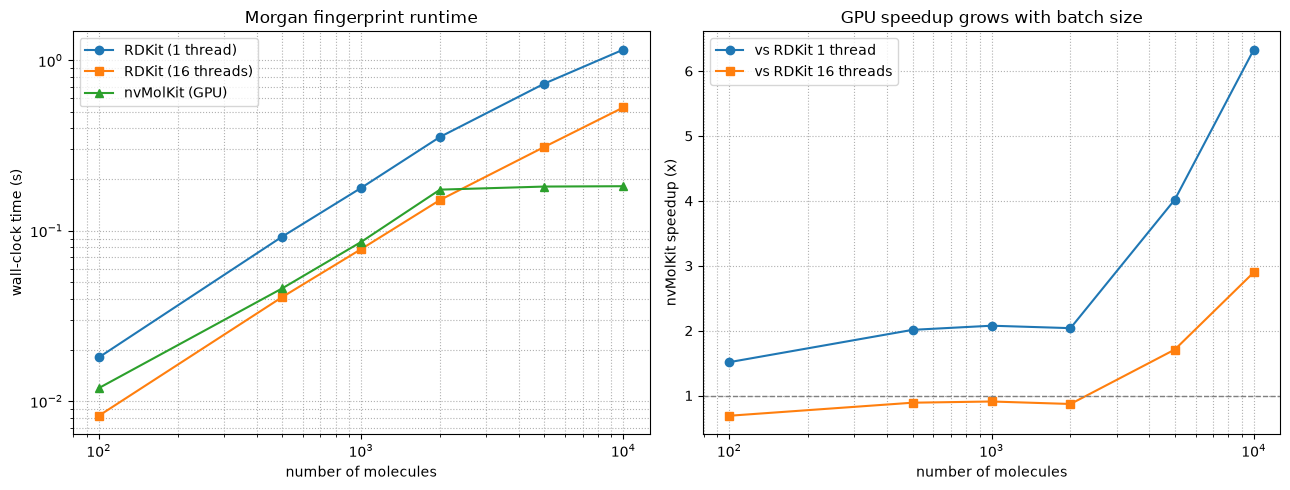

In [8]:
import matplotlib.pyplot as plt

col_rdN = f"rdkit_{N_CPU_THREADS}thread_s"
col_spN = f"speedup_vs_{N_CPU_THREADS}thread"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(df["n_mols"], df["rdkit_1thread_s"], "o-", label="RDKit (1 thread)")
ax1.plot(df["n_mols"], df[col_rdN], "s-", label=f"RDKit ({N_CPU_THREADS} threads)")
ax1.plot(df["n_mols"], df["nvmolkit_gpu_s"], "^-", label="nvMolKit (GPU)")
ax1.set_xlabel("number of molecules")
ax1.set_ylabel("wall-clock time (s)")
ax1.set_title("Morgan fingerprint runtime")
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.legend(); ax1.grid(True, which="both", ls=":")

ax2.plot(df["n_mols"], df["speedup_vs_1thread"], "o-", label="vs RDKit 1 thread")
ax2.plot(df["n_mols"], df[col_spN], "s-", label=f"vs RDKit {N_CPU_THREADS} threads")
ax2.axhline(1.0, color="gray", ls="--", lw=1)
ax2.set_xlabel("number of molecules")
ax2.set_ylabel("nvMolKit speedup (x)")
ax2.set_title("GPU speedup grows with batch size")
ax2.set_xscale("log")
ax2.legend(); ax2.grid(True, which="both", ls=":")

plt.tight_layout()
plt.show()

## 9. Takeaways

- **Same answer.** nvMolKit's Morgan fingerprints are bit-identical to RDKit's, so the GPU path is a drop-in
  replacement for the descriptor itself.
- **The win grows with batch size.** On small inputs, GPU launch + CPU preprocessing overhead dominates and the
  speedup is modest (or below 1x). As the library grows into the thousands, the GPU stays saturated and the
  speedup climbs — which is exactly the regime that matters for virtual screening and library-scale clustering.
- **Throughput, not latency.** nvMolKit is built for *total wall time across a large batch*. For a one-off
  single-molecule fingerprint, plain RDKit is still the right tool.

Numbers depend on your GPU, CPU core count, and the `radius`/`fpSize` settings — re-run with your own values to
profile your hardware.

**Next:** Tutorial 2 chains these fingerprints into bulk Tanimoto similarity, where the GPU advantage is even
larger (the similarity matrix is O(n²)).